# **`Fraud Detection`**
### **Notebook: 01 – Data Science & Exploratory Data Analysis (EDA)**

**Objective:**  
This notebook focuses on understanding, cleaning, transforming, and visualizing the credit risk dataset to prepare it for downstream Machine Learning tasks

**Key Tasks:**

- Load dataset  
- Inspect structure  
- Clean missing/invalid values  
- Correct datatypes  
- Remove outliers  
- Explore sales trends  
- Export cleaned dataset

### **`IMPORTING REQUIRED LIBRARIES`**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

from prettytable import PrettyTable
from IPython.display import display, Markdown

In [62]:
from scipy import stats
pd.set_option("display.max_columns", None)

from scipy.stats import (
    skew, kurtosis, shapiro, kstest, normaltest,
    chi2_contingency, f_oneway, pearsonr, spearmanr
)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer

### **`LOADING THE DATASET`**

In [4]:
file_path = r"C:\Users\tejas\OneDrive\Desktop\CPMLF Capstone Projects\FRAUD DETECTION\data\raw\creditcard.csv"

In [5]:
df = pd.read_csv(file_path)

In [6]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### **`QUICK INSPECTION`**

In [7]:
print("First 5 rows: ", df.head())


First 5 rows:     Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26      

In [8]:
print("Last 5 rows:", df.tail())

Last 5 rows:             Time         V1         V2        V3        V4        V5  \
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
284802 -2.606837 -4.918215  7.305334  1.914428  ...  0.213454  0.111864   
284803  1.058415  0.024330  0.294869  0.584800  ...  0.214205  0.924384   
284804  3.031260 -0.296827  0.708417  0.432454  ...  0.232045  0.578229   
284805  0.623708 -0.686180  0.679145  0.392087  ...  0.265245  0.800049   
284806 -0.649617  1.577006 -0.414650  0.486180  ...  0.261057  0.643078   

             V23       V24       V25       V26       V27       V28  Amount  \
284802  1.014480 -0.50934

In [9]:
df.select_dtypes(include=[np.number]).head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.select_dtypes(include="object").tail(5)

""
284802
284803
284804
284805
284806


In [11]:
print("\n|------------------------------------------------------ DESCRIPTIVE STATS -----------------------------------------------------|")
df.describe(
    include='all'
).T


|------------------------------------------------------ DESCRIPTIVE STATS -----------------------------------------------------|


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
print("\n|------------------------------------------------------ DESCRIBE -----------------------------------------------------|")
df.describe(include='all')


|------------------------------------------------------ DESCRIBE -----------------------------------------------------|


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [14]:
df.shape

(284807, 31)

**CHECKING DATASET SUMMARY**

In [15]:
table = PrettyTable()
table.field_names = ["Metric", "Value"]

table.add_row(["Total Rows", df.shape[0]])
table.add_row(["Total Columns", df.shape[1]])
table.add_row(["Duplicate Rows", df.duplicated().sum()])
table.add_row(["Columns with Nulls", df.isnull().any().sum()])

table.align = "l"

print(table)

+--------------------+--------+
| Metric             | Value  |
+--------------------+--------+
| Total Rows         | 284807 |
| Total Columns      | 31     |
| Duplicate Rows     | 1081   |
| Columns with Nulls | 0      |
+--------------------+--------+


**Checking for Data Types Summary**

In [16]:
dtype_counts = df.dtypes.value_counts()

dtype_table = PrettyTable()
dtype_table.field_names = ["Data Type", "Count"]

# Add rows
for dtype, count in dtype_counts.items():
    dtype_table.add_row([str(dtype), count])

# Left align the text
dtype_table.align = "l"

print("\nData Types Summary:")
# print("="*30)
print(dtype_table)


Data Types Summary:
+-----------+-------+
| Data Type | Count |
+-----------+-------+
| float64   | 30    |
| int64     | 1     |
+-----------+-------+


In [17]:
table = PrettyTable()
table.field_names = ["Column", "Data Type", "Missing", "Missing %", "Unique"]

for col in df.columns:
    dtype = df[col].dtype
    missing = df[col].isnull().sum()
    missing_pct = round((missing / len(df)) * 100, 2)
    unique = df[col].nunique()
    table.add_row([col, str(dtype), missing, f"{missing_pct}%", unique])

table.align = "l"

print("DataFrame Information Summary")
# print("="*35)
print(table)

DataFrame Information Summary
+--------+-----------+---------+-----------+--------+
| Column | Data Type | Missing | Missing % | Unique |
+--------+-----------+---------+-----------+--------+
| Time   | float64   | 0       | 0.0%      | 124592 |
| V1     | float64   | 0       | 0.0%      | 275663 |
| V2     | float64   | 0       | 0.0%      | 275663 |
| V3     | float64   | 0       | 0.0%      | 275663 |
| V4     | float64   | 0       | 0.0%      | 275663 |
| V5     | float64   | 0       | 0.0%      | 275663 |
| V6     | float64   | 0       | 0.0%      | 275663 |
| V7     | float64   | 0       | 0.0%      | 275663 |
| V8     | float64   | 0       | 0.0%      | 275663 |
| V9     | float64   | 0       | 0.0%      | 275663 |
| V10    | float64   | 0       | 0.0%      | 275663 |
| V11    | float64   | 0       | 0.0%      | 275663 |
| V12    | float64   | 0       | 0.0%      | 275663 |
| V13    | float64   | 0       | 0.0%      | 275663 |
| V14    | float64   | 0       | 0.0%      | 275663 

In [18]:
unique_cols = [col for col in df.columns if df[col].nunique() == df.shape[0]]

print("Most Possible Unique ID Columns:")
for col in unique_cols:
    print("-", col)

Most Possible Unique ID Columns:


In [19]:
unclean_table = PrettyTable()
unclean_table.field_names = ["Column Name", "Issue"]


for col in df.columns:
    issues = []
    if ' ' in col:
        issues.append("Contains space")
    if not col.isidentifier():
        issues.append("Invalid identifier")
    
    if issues:
        unclean_table.add_row([col, ', '.join(issues)])

# Aligning the text to the Left hand side
unclean_table.align = "l"


if unclean_table.rowcount > 0:
    print("Unclean Column Name Report: ")
    print("-" * 105)
    print(unclean_table)
else:
    print("All column Names are clean!!!")

All column Names are clean!!!


In [20]:
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_percent = (total_missing / total_cells) * 100

print(f"Overall Missing Data: {total_missing} values missing out of {total_cells} cells")
print(f"Total Missing Percentage: {missing_percent:.2f}%")

Overall Missing Data: 0 values missing out of 8829017 cells
Total Missing Percentage: 0.00%


### ***Cardinality Check for Categorical data***

In [21]:
cat_cols = df.select_dtypes(exclude=np.number).columns

for c in cat_cols:
    print(f"{c}: Unique - {df[c].nunique()}")

### ***Column Sematics Validation***

In [22]:
for col in df.columns:
    print(col, "->", df[col].dtype)

Time -> float64
V1 -> float64
V2 -> float64
V3 -> float64
V4 -> float64
V5 -> float64
V6 -> float64
V7 -> float64
V8 -> float64
V9 -> float64
V10 -> float64
V11 -> float64
V12 -> float64
V13 -> float64
V14 -> float64
V15 -> float64
V16 -> float64
V17 -> float64
V18 -> float64
V19 -> float64
V20 -> float64
V21 -> float64
V22 -> float64
V23 -> float64
V24 -> float64
V25 -> float64
V26 -> float64
V27 -> float64
V28 -> float64
Amount -> float64
Class -> int64


### ***Duplicate Records Analysis***

In [23]:
dup_rows = df.duplicated().sum()
dup_rows

1081

In [39]:
table = PrettyTable()
table.field_names = ["Metric", "Value"]

table.add_row(["Total Rows", df.shape[0]])
table.add_row(["Total Columns", df.shape[1]])
table.add_row(["Duplicate Rows", df.duplicated().sum()])
table.add_row(["Columns with Nulls", df.isnull().any().sum()])

table.align = "l"

print(table)

+--------------------+--------+
| Metric             | Value  |
+--------------------+--------+
| Total Rows         | 283726 |
| Total Columns      | 31     |
| Duplicate Rows     | 0      |
| Columns with Nulls | 0      |
+--------------------+--------+


### ***Numerical Distribution Summary:***

In [24]:
num_cols = df.select_dtypes(include=np.number).columns

dist_summary = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "std": df[num_cols].std(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "skewness": df[num_cols].apply(skew),
    "kurtosis": df[num_cols].apply(kurtosis)
})

dist_summary

,mean,median,std,min,max,skewness,kurtosis
Time,9.481386e+04,84692.000000,47488.145955,0.000000,172792.000000,-0.035567,-1.293528
V1,1.168375e-15,0.018109,1.958696,-56.407510,2.454930,-3.280650,32.486088
V2,3.416908e-16,0.065486,1.651309,-72.715728,22.057729,-4.624841,95.771404
V3,-1.379537e-15,0.179846,1.516255,-48.325589,9.382558,-2.240144,26.619062
V4,2.074095e-15,-0.019847,1.415869,-5.683171,16.875344,0.676289,2.635388
V5,9.604066e-16,-0.054336,1.380247,-113.743307,34.801666,-2.425889,206.900907
V6,1.487313e-15,-0.274187,1.332271,-26.160506,73.301626,1.826571,42.641724
V7,-5.556467e-16,0.040103,1.237094,-43.557242,120.589494,2.553894,405.600275
V8,1.213481e-16,0.022358,1.194353,-73.216718,20.007208,-8.521899,220.583080
V9,-2.406331e-15,-0.051429,1.098632,-13.434066,15.594995,0.554677,3.731224


**CHECKING FOR OUTLIERS**

<Axes: >

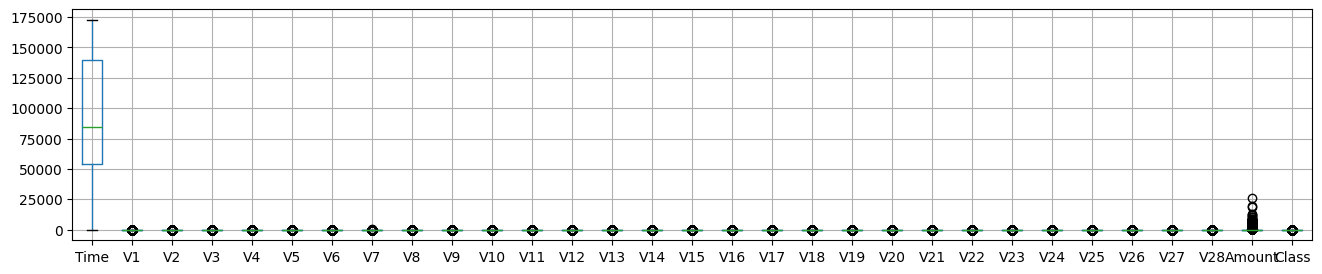

In [25]:
plt.figure(figsize=(16, 3))
df.boxplot()

## **DATA CLEANING**

## ***Cleaning Column Names (If Any)***

In [26]:
df_cleaned = df.copy()

In [27]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

print("- Column names standardized.")
df.columns

- Column names standardized.


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [28]:
cols_to_drop = ['Unnamed:_0.1', 'Unnamed:_0']
df.drop(columns=[col for col in cols_to_drop if col in df.columns],
        inplace=True)

In [29]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## ***Handling Missing Values***

In [30]:
missing = df.isnull().sum()
total_rows = df.shape[0]

missing_filtered = missing[missing > 0]
missing_percent = (missing_filtered / total_rows) * 100
filtered = missing_percent[missing_percent < 100].sort_values(ascending=False)

miss_table = PrettyTable()
miss_table.field_names = ["Column", "Missing Values", "Missing %"]

for col in filtered.index:
    miss_val = missing[col]
    miss_pct = filtered[col]
    miss_table.add_row([col, miss_val, f"{miss_pct:.2f}%"])

miss_table.align = "l"

print("|--------Missing Values Summary [Below 100% Only]---------|")
print(miss_table)

|--------Missing Values Summary [Below 100% Only]---------|
+--------+----------------+-----------+
| Column | Missing Values | Missing % |
+--------+----------------+-----------+
+--------+----------------+-----------+


### ***Numeric data***


In [31]:
for col in df_cleaned.select_dtypes(include=np.number).columns:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce') 
        median_val = df_cleaned[col].median()
        if np.isnan(median_val):   
            df_cleaned[col] = df_cleaned[col].fillna(0)  
            print(f"'{col}' had all NaNs filled with 0")
        else:
            df_cleaned[col] = df_cleaned[col].fillna(median_val)  

### ***Categorical data***

In [32]:
for col in df_cleaned.select_dtypes(include="object").columns:
    if df_cleaned[col].isnull().sum() > 0:
        missing_ratio = df_cleaned[col].isnull().mean()

        if missing_ratio > 0.5:  
            print(f"Dropping '{col}' because {missing_ratio:.2%} missing")
            df_cleaned.drop(columns=[col], inplace=True)
        else:
            mode_val = df_cleaned[col].mode()[0] if not df_cleaned[col].mode().empty else "Unknown"
            df_cleaned[col] = df_cleaned[col].fillna(mode_val)
            print(f"Filled '{col}' missing values with mode {mode_val}")

In [33]:
missing = df_cleaned.isnull().sum().sort_values(ascending=False)

miss_table = PrettyTable()
miss_table.field_names = ["Columns", "Missing Values", "Missing %"]
miss_table.align = "l"
total_rows = df_cleaned.shape[0]   

for col, val in missing.items():
    percent = (val / total_rows) * 100
    miss_table.add_row([col, val, f"{percent:.2f}%"])

print("\nMissing Values Summary [After Cleaning]: ")
print(miss_table)

key_observ = """
**Key Observations:**

- All columns have **0%** missing values after cleaning, indicating a complete dataset,
no further imputation or handling of missing values is required.
- This ensures that all features are ready for modeling without any risk of data loss or bias due to missing values.
"""

display(Markdown(key_observ))


Missing Values Summary [After Cleaning]: 
+---------+----------------+-----------+
| Columns | Missing Values | Missing % |
+---------+----------------+-----------+
| Time    | 0              | 0.00%     |
| V16     | 0              | 0.00%     |
| Amount  | 0              | 0.00%     |
| V28     | 0              | 0.00%     |
| V27     | 0              | 0.00%     |
| V26     | 0              | 0.00%     |
| V25     | 0              | 0.00%     |
| V24     | 0              | 0.00%     |
| V23     | 0              | 0.00%     |
| V22     | 0              | 0.00%     |
| V21     | 0              | 0.00%     |
| V20     | 0              | 0.00%     |
| V19     | 0              | 0.00%     |
| V18     | 0              | 0.00%     |
| V17     | 0              | 0.00%     |
| V15     | 0              | 0.00%     |
| V1      | 0              | 0.00%     |
| V14     | 0              | 0.00%     |
| V13     | 0              | 0.00%     |
| V12     | 0              | 0.00%     |
| V11     | 0 


**Key Observations:**

- All columns have **0%** missing values after cleaning, indicating a complete dataset,
no further imputation or handling of missing values is required.
- This ensures that all features are ready for modeling without any risk of data loss or bias due to missing values.


In [34]:
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_percent = (total_missing / total_cells) * 100

print(f"Overall Missing Data: {total_missing} values missing out of {total_cells} cells")
print(f"Total Missing Percentage: {missing_percent:.2f}%")

Overall Missing Data: 0 values missing out of 8829017 cells
Total Missing Percentage: 0.00%


### ***Handled Identified Issues in the Columns***

In [35]:
unclean_table = PrettyTable()
unclean_table.field_names = ["Column Name", "Issue"]


for col in df.columns:
    issues = []
    if ' ' in col:
        issues.append("Contains space")
    if not col.isidentifier():
        issues.append("No Issues Identified")
    
    if issues:
        unclean_table.add_row([col, ', '.join(issues)])

# Aligning the text to the Left hand side
unclean_table.align = "l"


if unclean_table.rowcount > 0:
    print("Unclean Column Name Report: ")
    print("-" * 105)
    print(unclean_table)
else:
    print("All column Names are clean!!!")

All column Names are clean!!!


### ***Dropping Unwanted Columns***

In [36]:
cols_to_drop = ["Unnamed: 0.1", "Unnamed: 0"]

df.drop(columns=[col for col in cols_to_drop if col in df.columns],
        inplace=True)

In [37]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### **Dropping Duplicated Values**

In [38]:
df = df.drop_duplicates()

## ***Checking for Outliers***

### ***7.1 Check before handling***

In [40]:
df_cleaned = df.copy()

<Axes: >

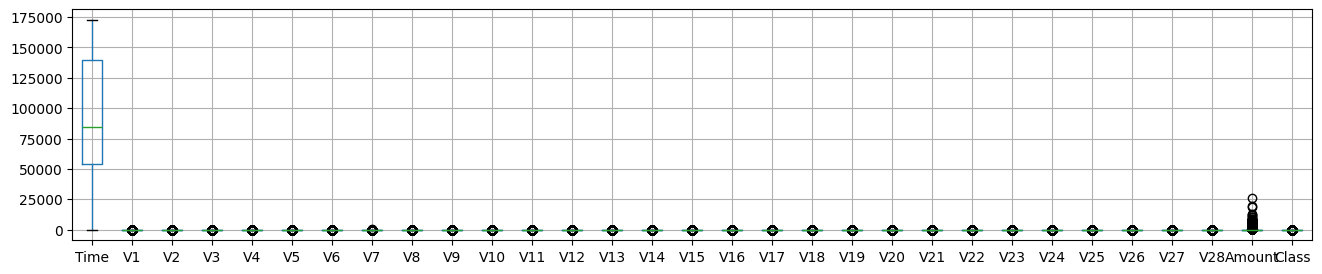

In [41]:
plt.figure(figsize=(16, 3))
df.boxplot()

### ***7.2 Handling Outliers using IQR Method***

In [42]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [43]:
for column in df_cleaned.columns:
    if df_cleaned[column].dtype != 'object': 
        lr,ur=remove_outlier(df_cleaned[column])
        df_cleaned[column]=np.where(df_cleaned[column]>ur,ur,df_cleaned[column])
        df_cleaned[column]=np.where(df_cleaned[column]<lr,lr,df_cleaned[column])

### ***7.3 Checking after handling outliers***

<Axes: >

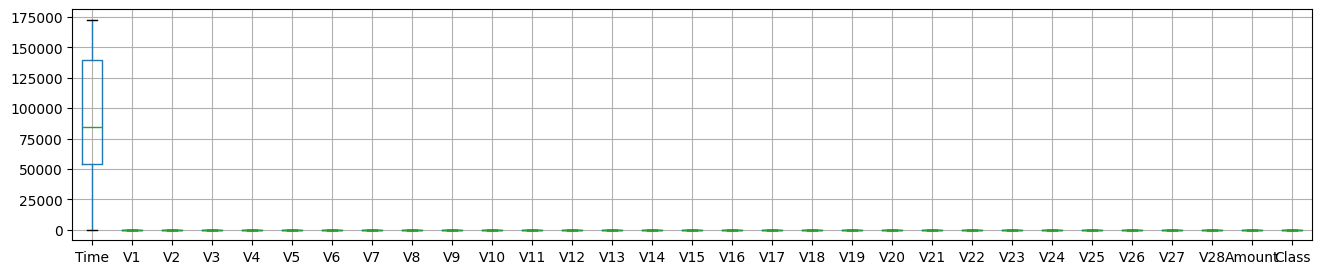

In [44]:
plt.figure(figsize=(16, 3))
df_cleaned.boxplot()

## **Target Distribution**

In [45]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [48]:
df["Class"].value_counts(normalize=True)

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

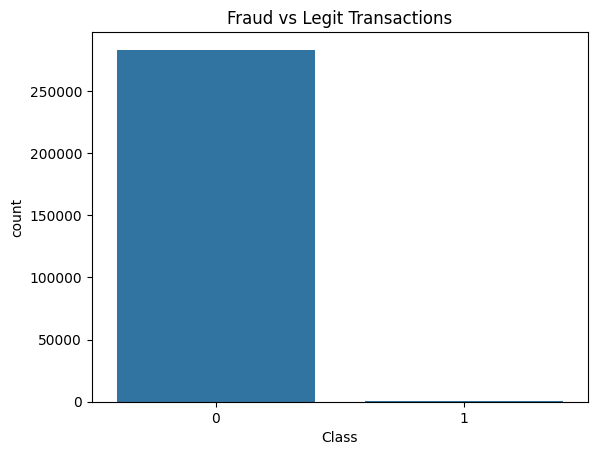


Interpretation:

- Dataset extremely imbalanced

- Accuracy is misleading

- Precision/Recall/ROC-AUC required




In [51]:
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Legit Transactions")
plt.show()

key_observation = """
Interpretation:

- Dataset extremely imbalanced

- Accuracy is misleading

- Precision/Recall/ROC-AUC required


"""

display(Markdown(key_observation))

## **Transaction Amount Analysis**

### **Distribution**

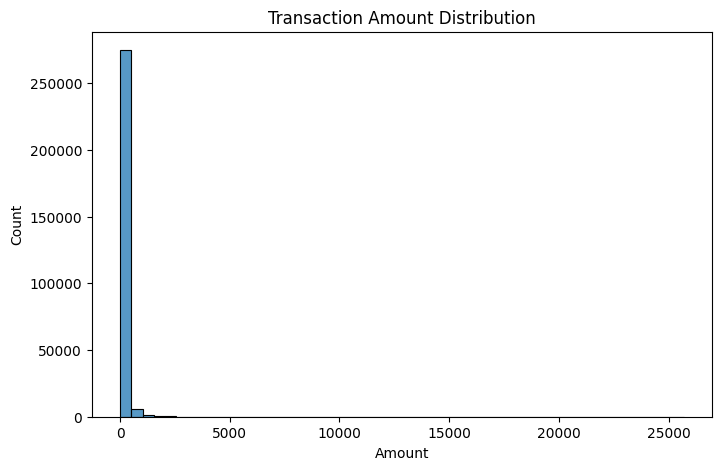

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

### **Fraud vs Legit amount**

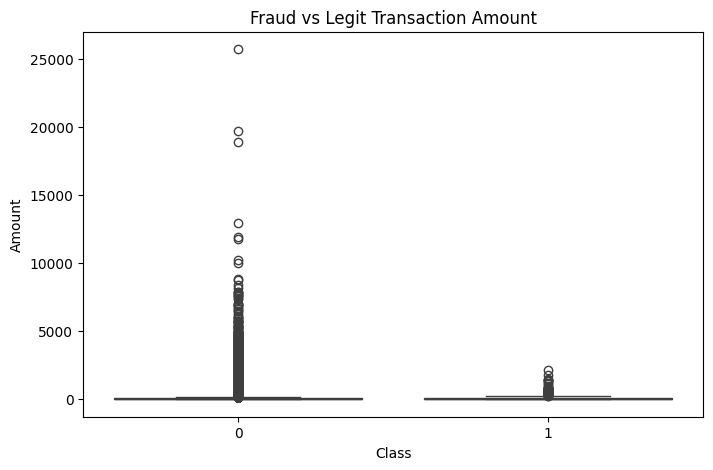


Interpretation:

- Fraud transactions often have different amount patterns than legitimate ones.




In [54]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Fraud vs Legit Transaction Amount")
plt.show()

key_obs = """
Interpretation:

- Fraud transactions often have different amount patterns than legitimate ones.


"""

display(Markdown(key_obs))

### **Time Feature Analysis**

In [55]:
df["Hour"] = (df["Time"] // 3600) % 24

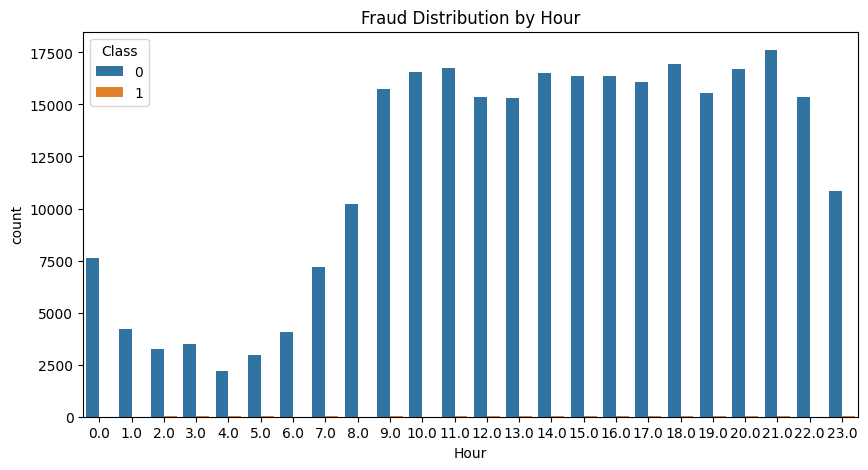

In [58]:
plt.figure(figsize=(10,5))
sns.countplot(x="Hour", hue="Class", data=df)
plt.title("Fraud Distribution by Hour")
plt.show()

### **Correaltion Analysis**

- ***Because features V1-V28 are PCA transformed, correlation insights are limited but still useful.***

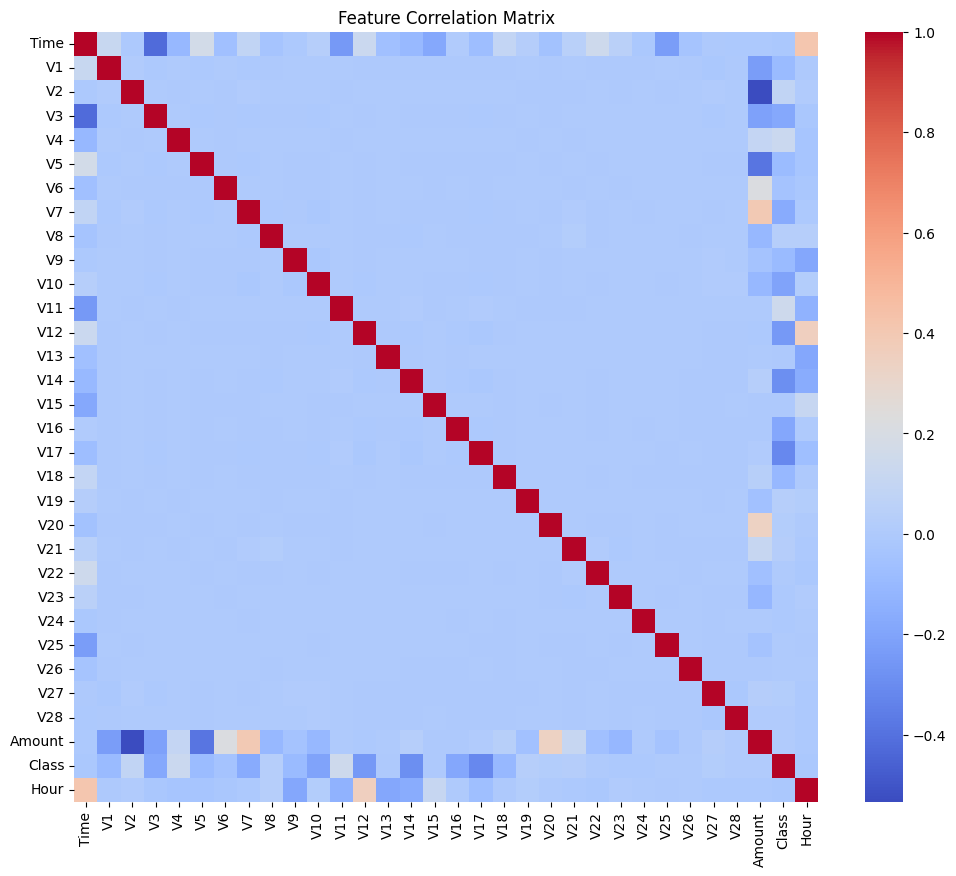

In [59]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

### **Fraud Feature Importance Exploration**

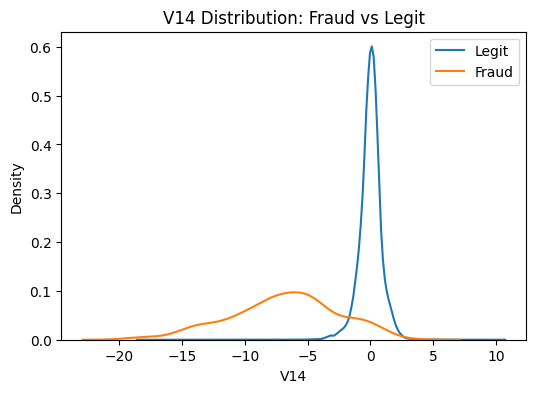

In [60]:
plt.figure(figsize=(6,4))
sns.kdeplot(df[df["Class"]==0]["V14"], label="Legit")
sns.kdeplot(df[df["Class"]==1]["V14"], label="Fraud")
plt.legend()
plt.title("V14 Distribution: Fraud vs Legit")
plt.show()

### **Outlier Detection**

In [63]:
z_scores = np.abs(stats.zscore(df["Amount"]))
outliers = df[z_scores > 3]

print("Potential outliers:", len(outliers))

Potential outliers: 4063


## **Class Imbalance Strategy Planning**

**Possible techniques:**

- SMOTE oversampling

- Undersampling

- Class weights

- Anomaly detection models

## **Converting Categorical Columns into Binary Dtype**

In [66]:
for feature in df_cleaned.columns:
    if df_cleaned[feature].dtype == 'object':
        print('\n')
        print('Features: ', feature)
        print(pd.Categorical(df_cleaned[feature].unique()))
        print(pd.Categorical(df_cleaned[feature].unique()).codes)
        df_cleaned[feature] = pd.Categorical(df_cleaned[feature]).codes

## ***Checking if everything is Fine***

In [67]:
table = PrettyTable()
table.field_names = ["Metric", "Value"]

table.add_row(["Total Rows", df_cleaned.shape[0]])
table.add_row(["Total Columns", df_cleaned.shape[1]])
table.add_row(["Duplicate Rows", df_cleaned.duplicated().sum()])
table.add_row(["Columns with Nulls", df_cleaned.isnull().any().sum()])

table.align = "l"

print(table)

+--------------------+--------+
| Metric             | Value  |
+--------------------+--------+
| Total Rows         | 283726 |
| Total Columns      | 31     |
| Duplicate Rows     | 0      |
| Columns with Nulls | 0      |
+--------------------+--------+


In [68]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0


## ***Saving the cleaned dataset***

In [69]:
cleaned_path = "../data/processed/creditcard_cleaned.csv"
df.to_csv(cleaned_path, index=False)

In [70]:
cleaned_path

'../data/processed/creditcard_cleaned.csv'

## **Key Findings**

- Dataset is extremely imbalanced (~0.17% fraud).

- Fraud transactions show different patterns in Amount distribution.

- Several PCA features (V10, V12, V14, V17) appear strongly related to fraud.

- No missing values present.

- Outliers exist but may represent real fraud cases.